In [11]:
import os
import sys
import django

# Establecer manualmente la ruta del proyecto
project_path = 'E:/Proyectos/proyecto_tesis/metaheuristics'  # Ajusta esta ruta a tu estructura de proyecto

# Añadir la ruta del proyecto al sys.path
if project_path not in sys.path:
    sys.path.append(project_path)

# Establecer la variable de entorno de Django settings
os.environ['DJANGO_SETTINGS_MODULE'] = 'metaheuristics.settings'  # Ajusta el nombre del módulo de configuración

# Inicializar Django
django.setup()

# Ahora puedes importar los módulos usando importaciones absolutas
from vrp.Problema_CVRP import CVRP
from vrp.Lectura_Instancia import VRPFileReader
from vrp.Algoritmo_Genetico_CVRP import GeneticAlgorithm,Fitness
from vrp.tables_genetic import GeneticAlgorithmTable


In [12]:
from django.conf import settings

file_path = os.path.join(settings.BASE_DIR, 'vrp', 'static', 'instancias', 'Golden/Golden_1.vrp')
#output_path = os.path.join(settings.BASE_DIR, 'vrp', 'pruebas', 'grafico_prueba.png')
cvrp = CVRP(file_path=file_path)

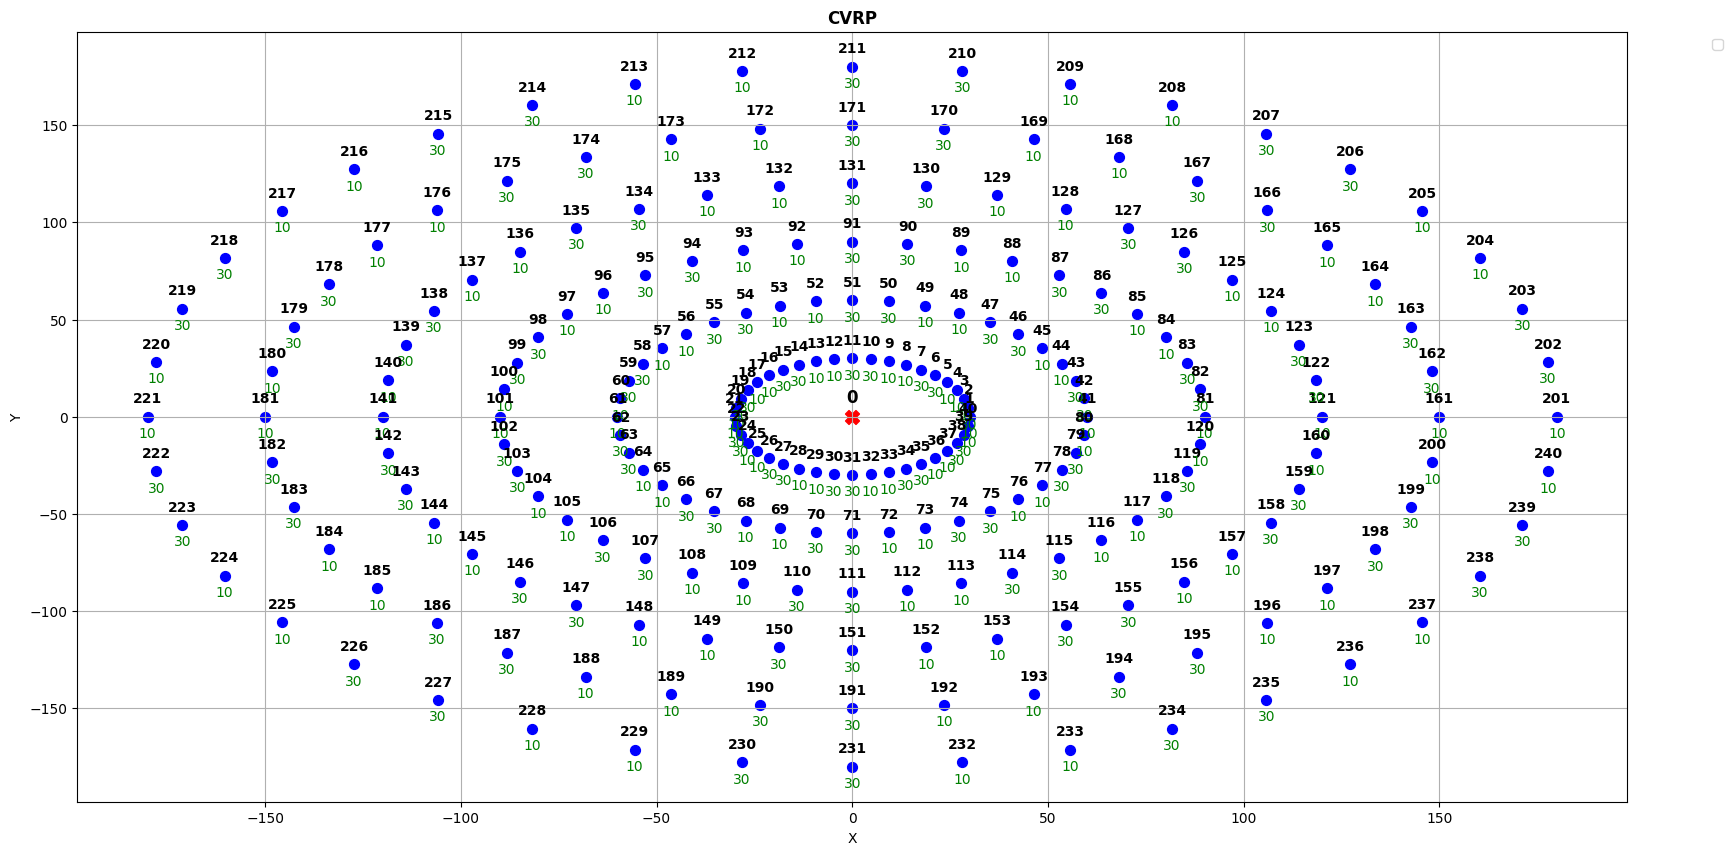

In [4]:
cvrp.graficar()


In [5]:
ag = GeneticAlgorithm(cvrp=cvrp, population_size=100, num_generations=100, mutation_rate=0.01, use_elitism=True)

In [6]:
ind,cost,rutas = ag.evolve()

In [7]:
print(ind)

[38, 3, 138, 104, 142, 70, 30, 10, 88, 47, 125, 46, 20, 31, 105, 151, 111, 79, 45, 35, 5, 234, 195, 153, 161, 26, 14, 83, 82, 43, 117, 71, 34, 185, 66, 107, 190, 193, 112, 222, 24, 61, 178, 179, 176, 92, 19, 27, 174, 214, 130, 172, 110, 59, 100, 102, 78, 154, 200, 150, 191, 29, 115, 18, 188, 230, 113, 232, 141, 25, 17, 237, 163, 60, 183, 187, 224, 99, 98, 137, 147, 63, 9, 157, 128, 124, 203, 76, 126, 64, 235, 119, 155, 69, 40, 160, 197, 39, 90, 136, 55, 22, 205, 159, 201, 204, 162, 6, 56, 220, 1, 4, 37, 36, 196, 210, 213, 131, 212, 13, 89, 118, 156, 229, 144, 42, 75, 80, 73, 149, 121, 166, 86, 168, 2, 114, 233, 192, 194, 140, 52, 50, 215, 218, 223, 94, 91, 93, 58, 21, 68, 33, 74, 231, 145, 143, 182, 180, 216, 65, 32, 207, 206, 53, 11, 198, 122, 164, 123, 84, 77, 228, 109, 72, 23, 175, 184, 227, 226, 225, 97, 209, 169, 146, 108, 101, 135, 165, 236, 28, 219, 103, 177, 173, 127, 15, 62, 67, 106, 152, 238, 240, 85, 49, 133, 129, 211, 171, 95, 217, 181, 186, 189, 148, 87, 158, 51, 134, 170,

In [8]:
print(cost)

23709.600438940335


In [9]:
print(rutas)

[[38, 3, 138, 104, 142, 70, 30, 10, 88, 47, 125, 46, 20, 31, 105, 151, 111, 79, 45, 35, 5, 234, 195], [153, 161, 26, 14, 83, 82, 43, 117, 71, 34, 185, 66, 107, 190, 193, 112, 222, 24, 61, 178, 179, 176, 92, 19, 27], [174, 214, 130, 172, 110, 59, 100, 102, 78, 154, 200, 150, 191, 29, 115, 18, 188, 230, 113, 232, 141, 25, 17, 237, 163, 60], [183, 187, 224, 99, 98, 137, 147, 63, 9, 157, 128, 124, 203, 76, 126, 64, 235, 119, 155, 69, 40, 160, 197, 39, 90, 136, 55], [22, 205, 159, 201, 204, 162, 6, 56, 220, 1, 4, 37, 36, 196, 210, 213, 131, 212, 13, 89, 118, 156, 229, 144, 42, 75, 80, 73, 149, 121, 166, 86, 168], [2, 114, 233, 192, 194, 140, 52, 50, 215, 218, 223, 94, 91, 93, 58, 21, 68, 33, 74, 231, 145, 143, 182, 180, 216, 65, 32], [207, 206, 53, 11, 198, 122, 164, 123, 84, 77, 228, 109, 72, 23, 175, 184, 227, 226, 225, 97, 209, 169, 146, 108, 101, 135, 165, 236, 28], [219, 103, 177, 173, 127, 15, 62, 67, 106, 152, 238, 240, 85, 49, 133, 129, 211, 171, 95, 217, 181, 186, 189, 148, 87, 158

In [10]:
cvrp.deposito.Q
cvrp.num_clientes

240

### Probando un nuevo enfoque

In [11]:
class GreadyAlgorithm:
    def __init__(self,cvrp):
        self.cvrp = cvrp
        self.num_customers = cvrp.num_clientes
        self.capacity = cvrp.deposito.Q
        self.distances = cvrp.matriz_distancias
        self.nodo_actual = 0
        self.visited = [0] * self.num_customers
        self.demanda_actual = 0

    
    def can_visit(self,cliente):
        cond1 = cliente!=self.nodo_actual
        cond2 = self.visited[cliente-1] < 1
        cond3 = self.demanda_actual + self.cvrp.demandas[cliente-1] <= self.capacity
        return cond1 and cond2 and cond3

    def get_targets(self,clientes):
        return list(filter(self.can_visit,clientes))        

    # Creamos nuestro gready que retorna un individuo solucion
    def get_individual(self):
        
        route = [] # individuo que retornaremos
        # Creamos un buckle
        while not all(self.visited):
            # Obtenemos los clientes que se pueden visitar
            targets = self.get_targets(list(range(1,self.num_customers+1)))
            
            if targets :
                # Obtenemos el target con la minima distancia
                target = min(targets,key=lambda x: self.distances[self.nodo_actual][x])
                # Actualizamos la demanda
                self.demanda_actual += self.cvrp.demandas[target-1]
                # Actualizamos el nodo actual
                self.nodo_actual = target
                # Agregamos el target a la ruta
                route.append(target)
                # Marcamos el target como visitado
                self.visited[target-1] = 1
            else:
                # Actualizamos el nodo actual al deposito
                self.nodo_actual = 0
                # Actualizamos la demanda
                self.demanda_actual = 0
        
        return route

In [12]:
alg = GreadyAlgorithm(cvrp)

In [13]:
individual = alg.get_individual()

In [14]:
print(individual)

[2, 1, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 13, 12, 10, 11, 9, 8, 7, 6, 5, 4, 3, 43, 42, 41, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 65, 14, 15, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 66, 106, 105, 104, 103, 102, 101, 100, 99, 98, 97, 96, 95, 93, 92, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 94, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 44, 84, 83, 82, 81, 120, 119, 118, 117, 116, 115, 114, 113, 112, 111, 110, 109, 108, 107, 150, 151, 152, 153, 154, 155, 156, 157, 197, 196, 86, 85, 87, 88, 89, 90, 91, 131, 130, 129, 128, 127, 126, 125, 124, 123, 122, 121, 160, 159, 158, 198, 199, 200, 161, 201, 240, 132, 133, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 235, 236, 237, 233, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 212, 211, 210, 209, 208, 207, 206, 205, 204, 203, 202, 239, 238, 234, 216, 21

In [15]:
#Decodificamos el individuo
routes = Fitness(distance_matrix=cvrp.matriz_distancias, demands= cvrp.demandas, vehicle_capacity= cvrp.deposito.Q).decode_individual(individual)
routes

[[2,
  1,
  40,
  39,
  38,
  37,
  36,
  35,
  34,
  33,
  32,
  31,
  30,
  29,
  28,
  27,
  26,
  25,
  24,
  23,
  22,
  21,
  20,
  19,
  18,
  17,
  16,
  13,
  12],
 [10,
  11,
  9,
  8,
  7,
  6,
  5,
  4,
  3,
  43,
  42,
  41,
  80,
  79,
  78,
  77,
  76,
  75,
  74,
  73,
  72,
  71,
  70,
  69,
  68,
  67,
  65],
 [14,
  15,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  66,
  106,
  105,
  104,
  103,
  102,
  101,
  100,
  99,
  98,
  97,
  96,
  95,
  93,
  92],
 [45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  94,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149],
 [44,
  84,
  83,
  82,
  81,
  120,
  119,
  118,
  117,
  116,
  115,
  114,
  113,
  112,
  111,
  110,
  109,
  108,
  107,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  197,
  196],
 [86,
  85,
  87,
  88,
  89,
  90,
  91,
  131,
  130,
  129,
  128,
  127,
  126,
  125,
  124,
  123,
  122,
  121,
  16

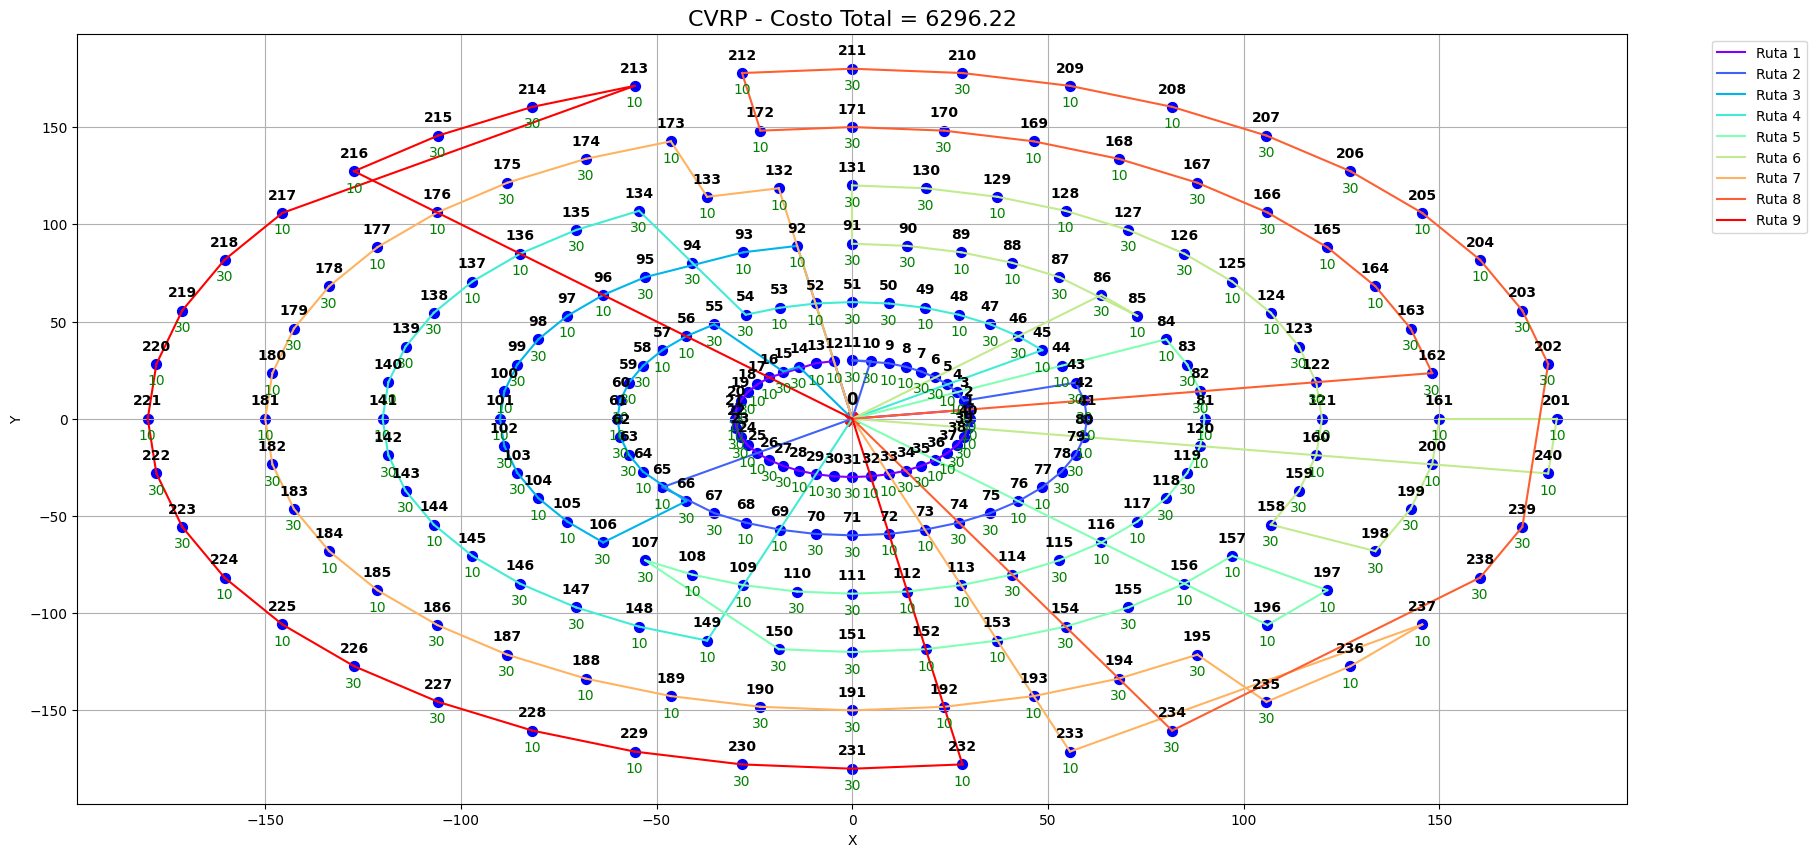

In [16]:
cvrp.graficar(rutas=routes)

In [17]:
# Uso de filter vs uso de map
# filter(funcion,iterable) -> retorna un iterable con los elementos que cumplen la condicion
# map(funcion,iterable) -> retorna un iterable con los elementos que cumplen la condicion

# Ejemplo de uso de filter
def es_par(n):
    return n*2

numeros = [1,2,3,4,5,6,7,8,9,10]
filtered = list(filter(es_par,numeros))
print(filtered)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [18]:
# Ejemplo de map
def es_par(n):
    return n%2 == 0

numeros = [1,2,3,4,5,6,7,8,9,10]
mapeado = list(map(es_par,numeros))
print(mapeado)

[False, True, False, True, False, True, False, True, False, True]


# Rellenado de poblacion

In [19]:
# Luego de hacer el gready rellenaremos la poblacion con individuos modificados del gready original
# Como un cruzamiento consigo mismo previo al algoritmo genetico


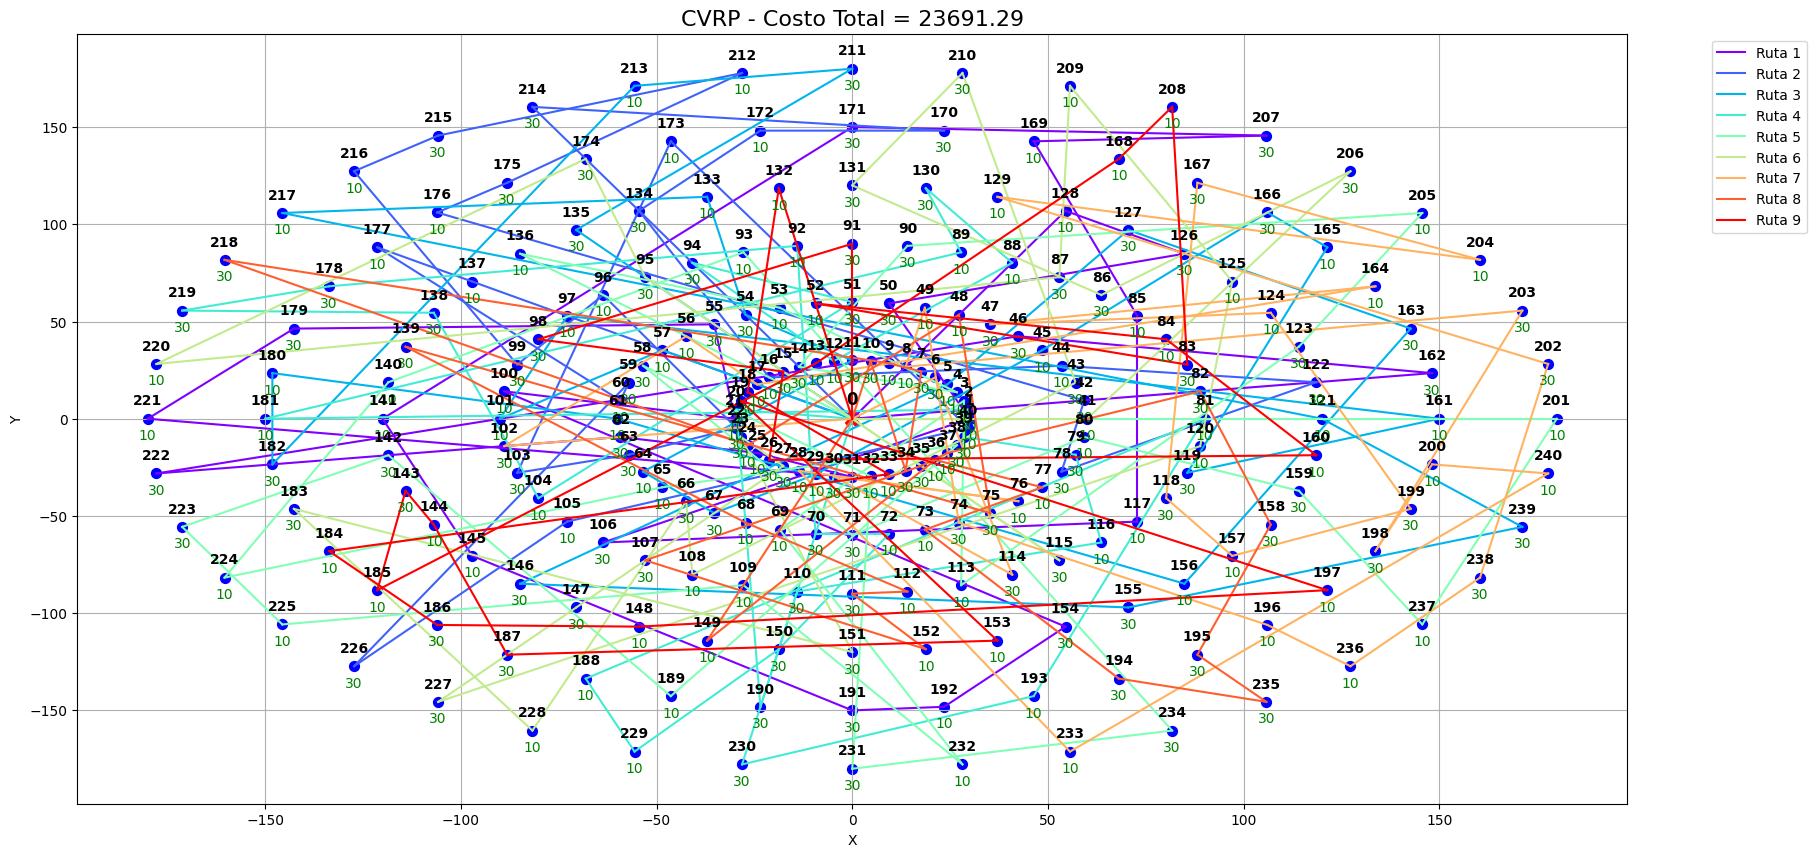

In [20]:
# Probamos el algoritmo genetico
ag = GeneticAlgorithm(cvrp=cvrp, population_size=100, num_generations=100, mutation_rate=0.01, use_elitism=True)
ind,cost,rutas = ag.evolve()
cvrp.graficar(rutas=rutas)

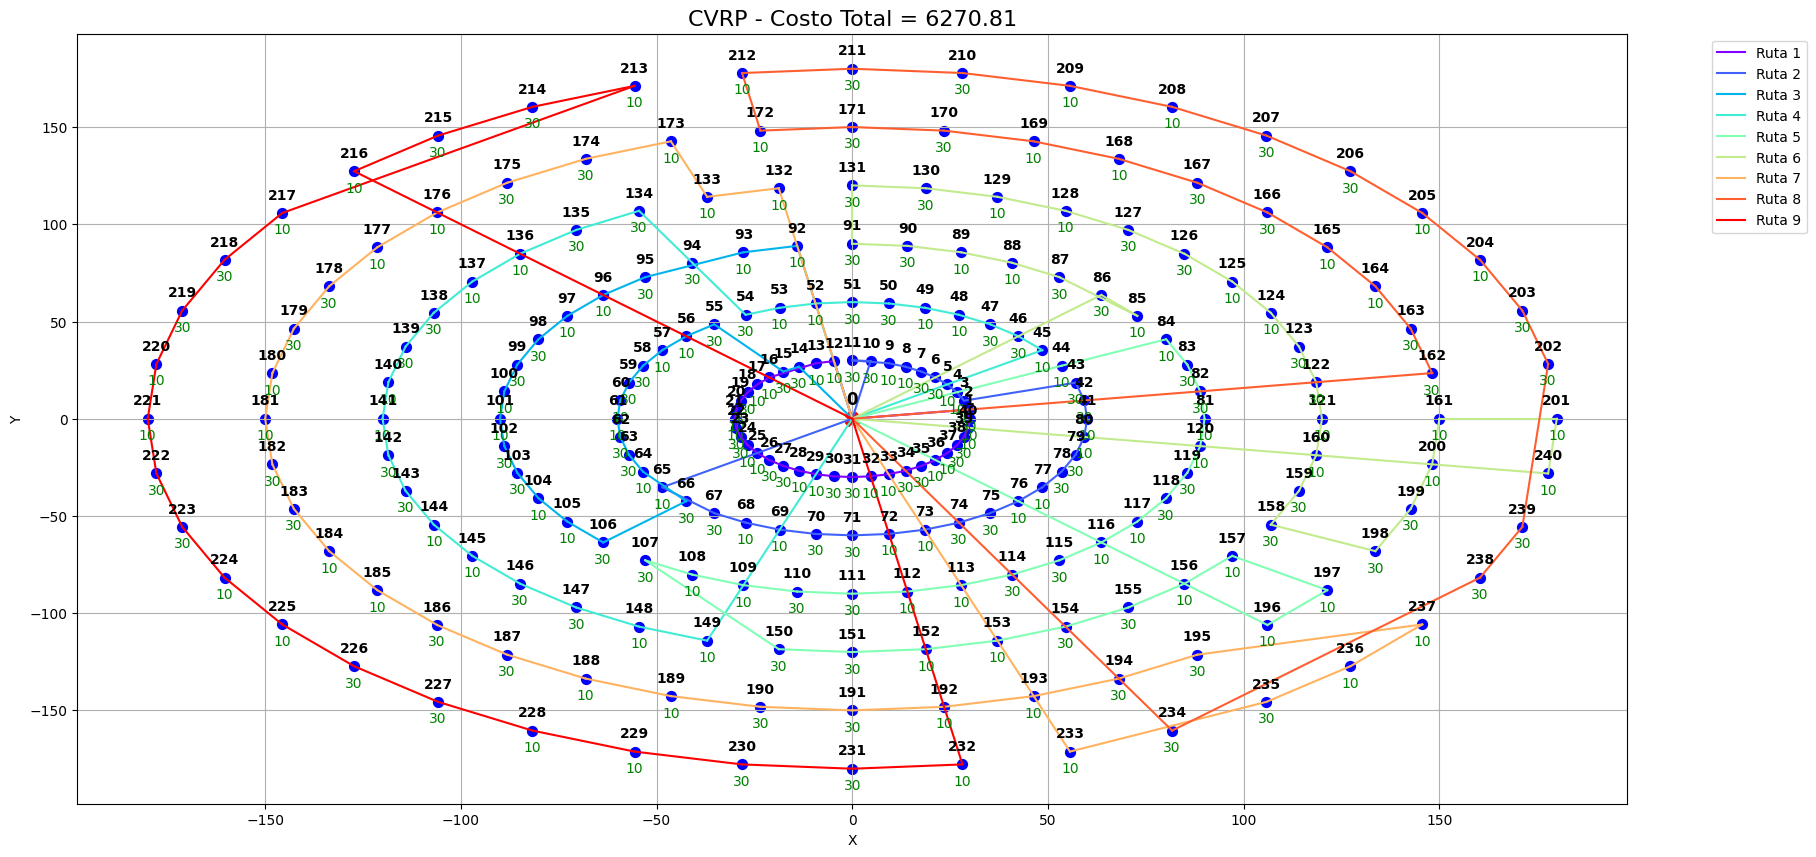

In [21]:
from vrp.Algoritmo_Genetico_CVRP import GeneticAlgorithm
# Probamos el algoritmo genetico
ag = GeneticAlgorithm(cvrp=cvrp, population_size=100, num_generations=100, mutation_rate=0.01, use_elitism=True,gready=True)
ind,cost,rutas = ag.evolve()
cvrp.graficar(rutas=rutas)

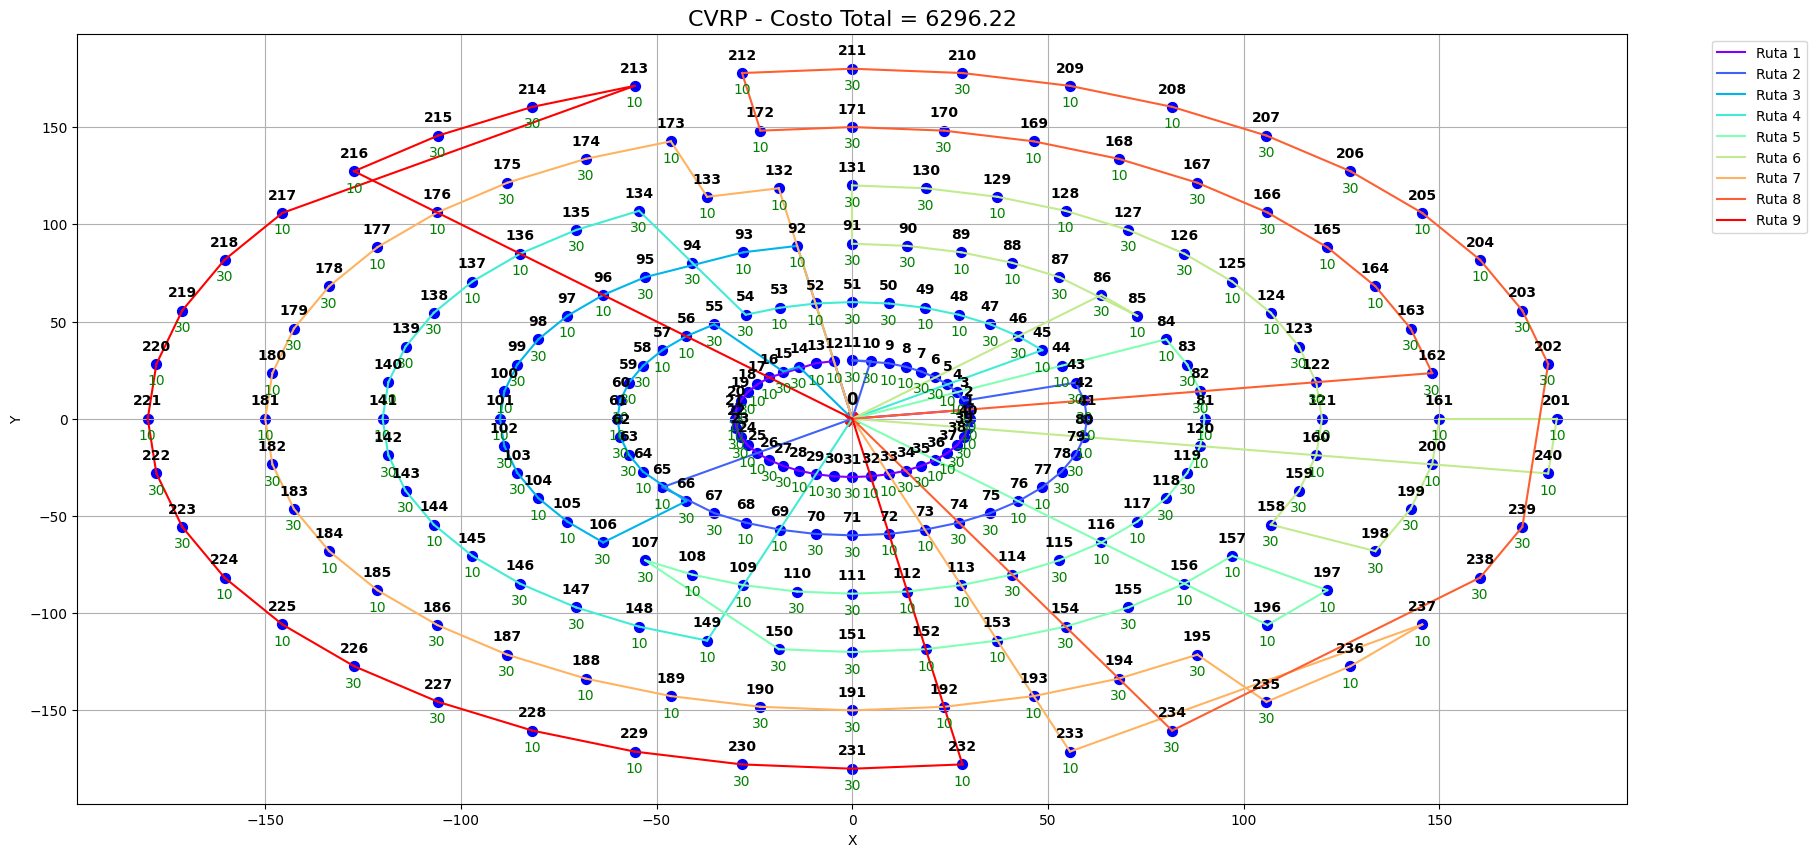

In [22]:
from vrp.Algoritmo_Genetico_CVRP import GeneticAlgorithm
# Probamos el algoritmo genetico
ag = GeneticAlgorithm(cvrp=cvrp, population_size=100, num_generations=600, mutation_rate=0.01, use_elitism=True,gready=True,homogenia=False)
ind,cost,rutas = ag.evolve()
cvrp.graficar(rutas=rutas)

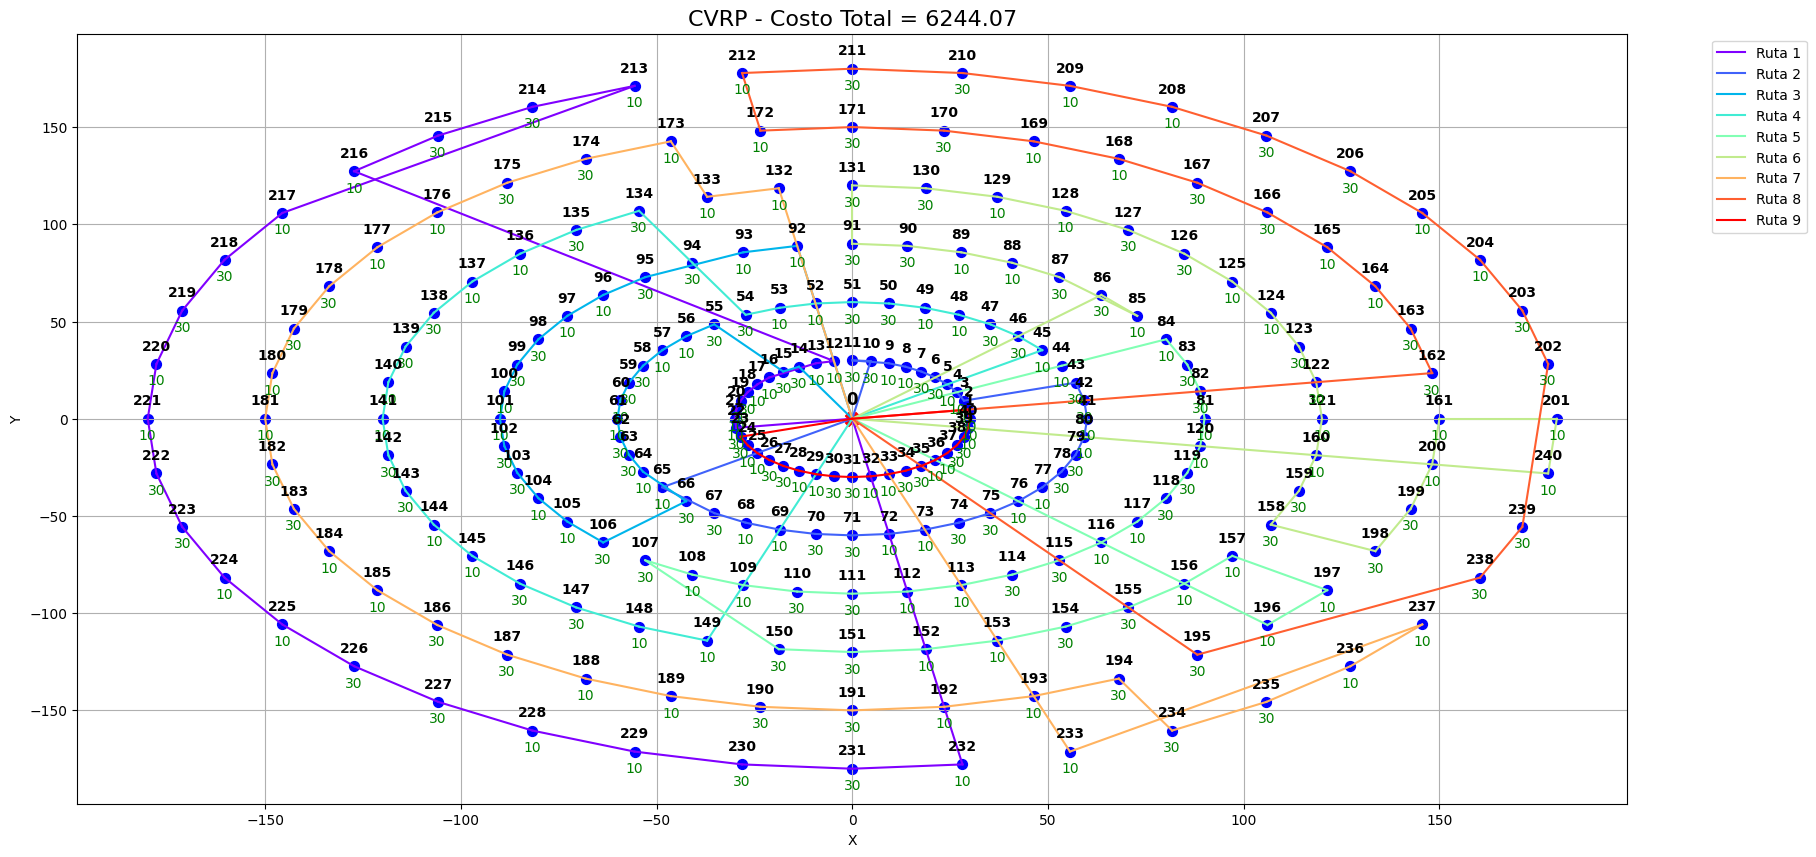

In [23]:
from vrp.Algoritmo_Genetico_CVRP import GeneticAlgorithm
# Probamos el algoritmo genetico
ag = GeneticAlgorithm(cvrp=cvrp, population_size=50, num_generations=1000, mutation_rate=0.02, use_elitism=True,gready=True)
ind,cost,rutas = ag.evolve()
cvrp.graficar(rutas=rutas)

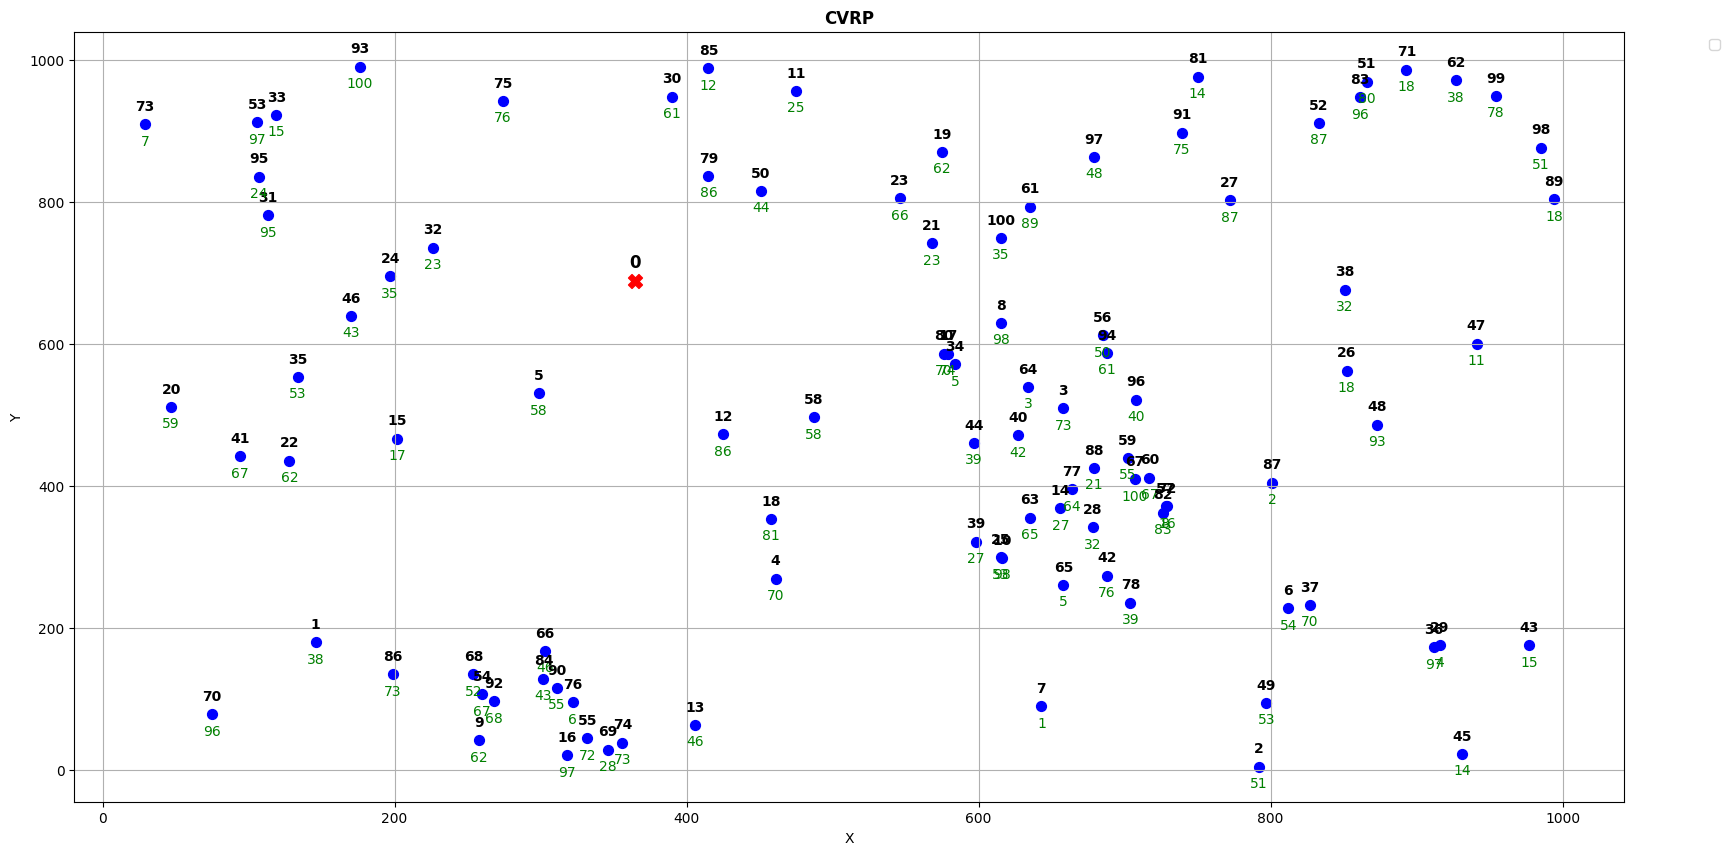

In [24]:
from django.conf import settings

file_path = os.path.join(settings.BASE_DIR, 'vrp', 'static', 'instancias', 'X/X-n101-k25.vrp')
#output_path = os.path.join(settings.BASE_DIR, 'vrp', 'pruebas', 'grafico_prueba.png')
cvrp = CVRP(file_path=file_path)
# grafiacmos la instancia
cvrp.graficar()

In [25]:
from vrp.Lectura_Instancia import VRPFileReader
# Solucion
file_path_solution = os.path.join(settings.BASE_DIR, 'vrp', 'static', 'instancias', 'X/X-n101-k25.sol')
sol , cost = VRPFileReader.read_sol_file(file_path_solution)

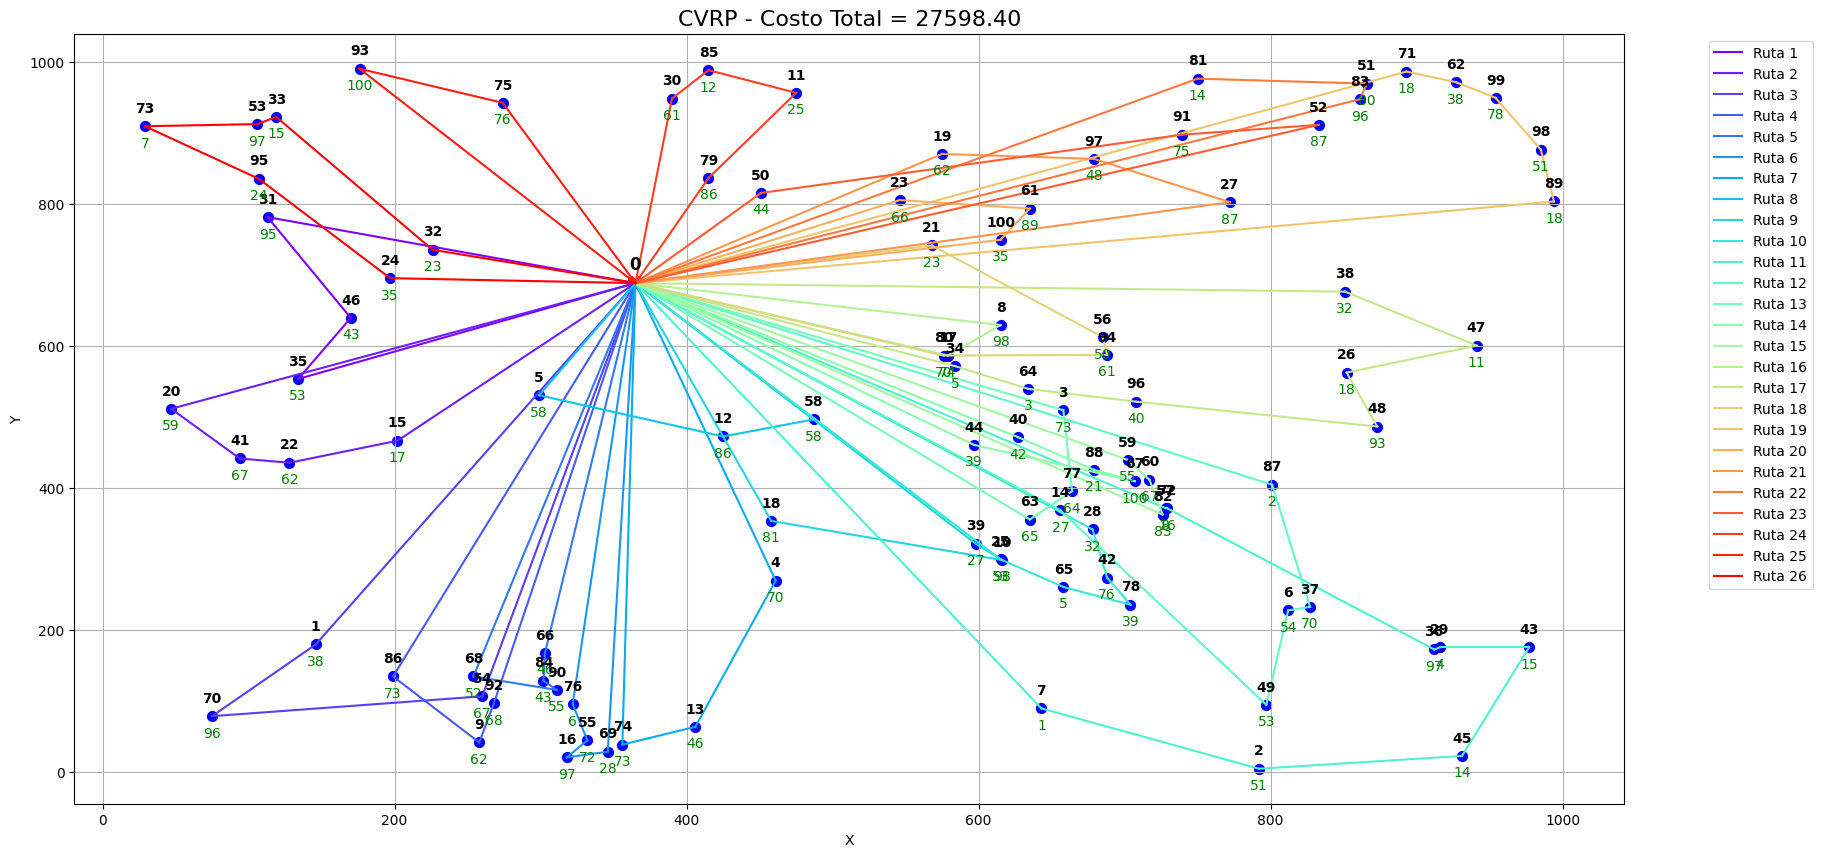

In [26]:
cvrp.graficar(rutas=sol)

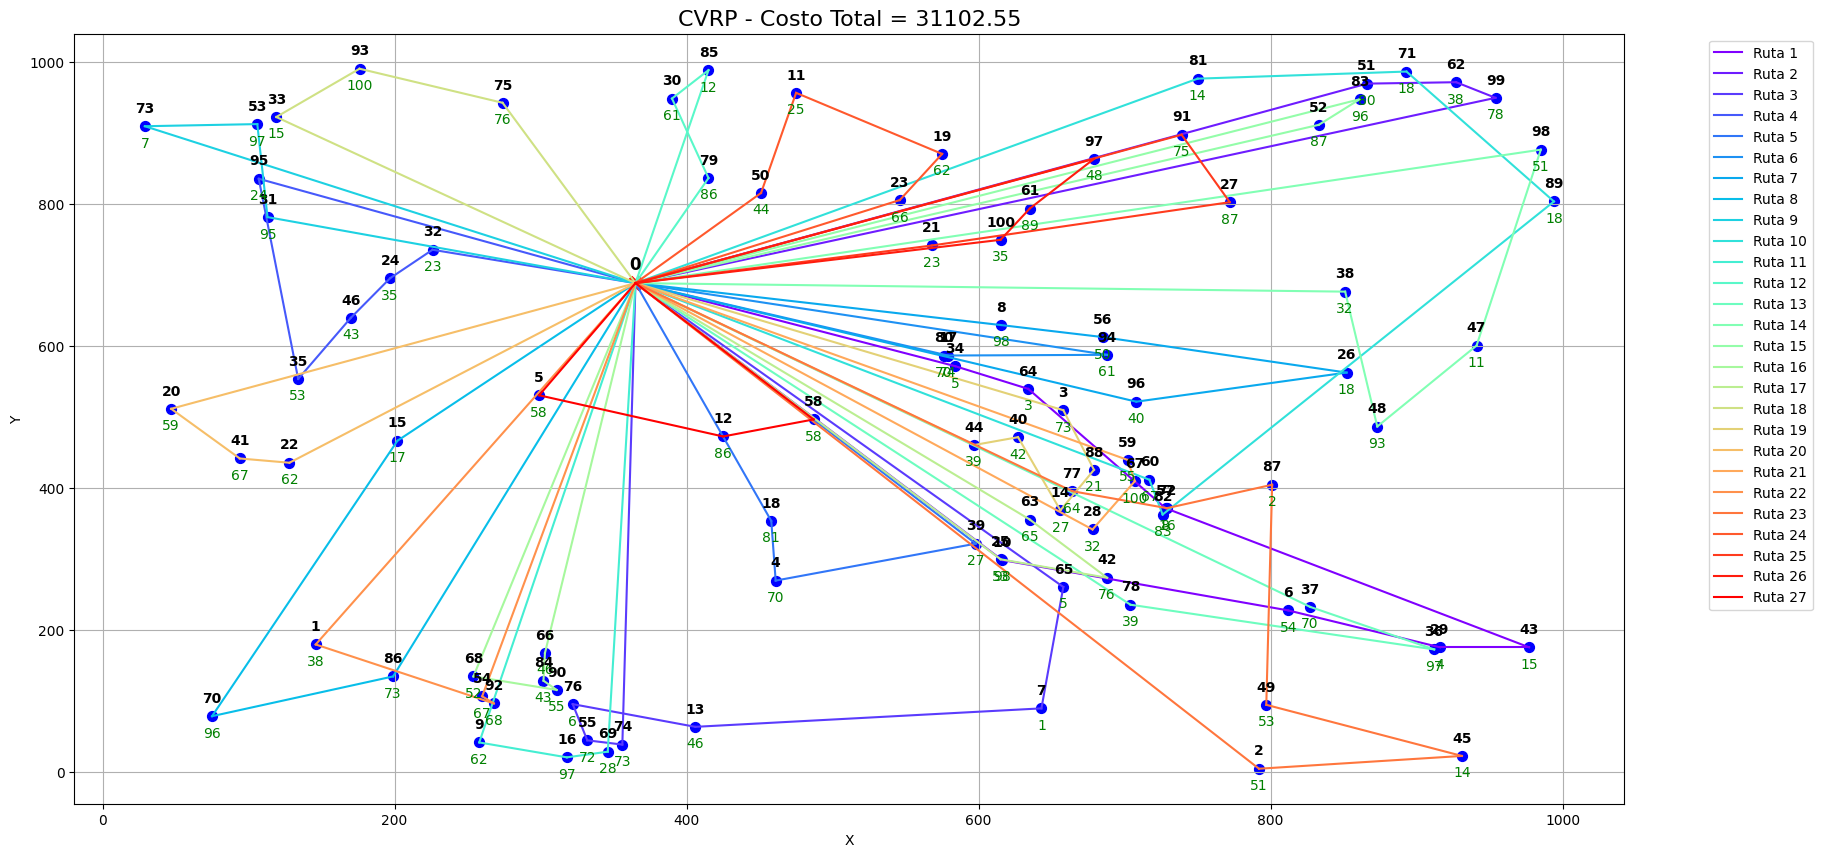

In [27]:
from vrp.Algoritmo_Genetico_CVRP import GeneticAlgorithm
# Probamos el algoritmo genetico
ag = GeneticAlgorithm(cvrp=cvrp, population_size=50, num_generations=1000, mutation_rate=0.02, use_elitism=True,gready=True)
ind,cost,rutas = ag.evolve()
cvrp.graficar(rutas=rutas)

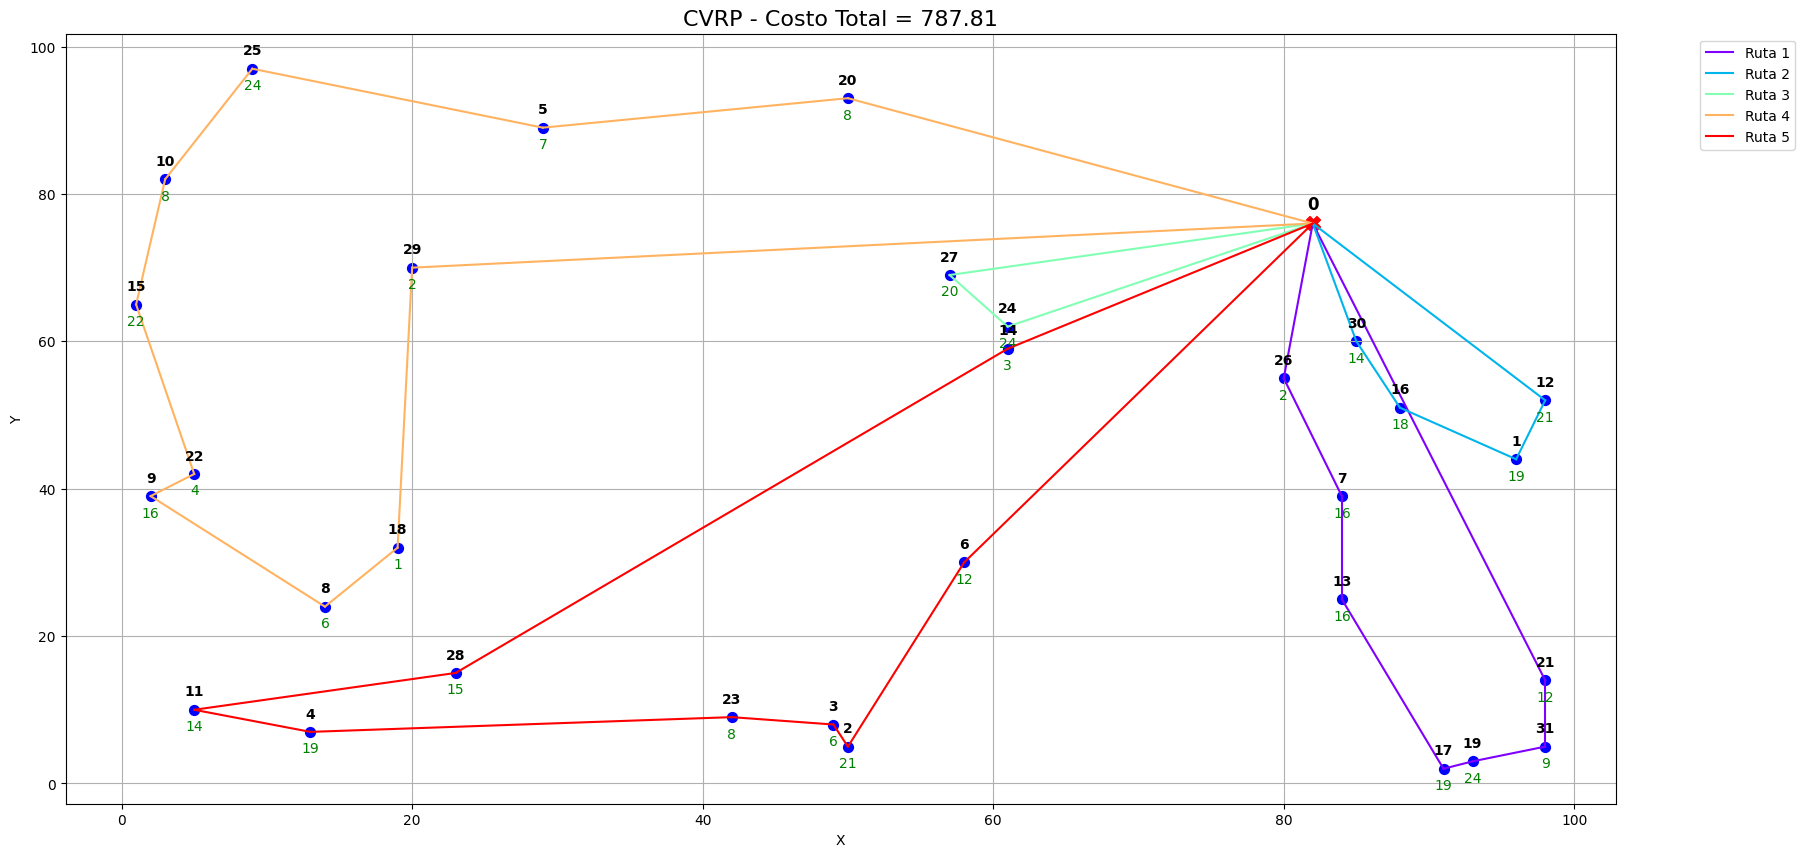

In [28]:
from django.conf import settings
from vrp.Lectura_Instancia import VRPFileReader

file_path = os.path.join(settings.BASE_DIR, 'vrp', 'static', 'instancias', 'A/A-n32-k5.vrp')
#output_path = os.path.join(settings.BASE_DIR, 'vrp', 'pruebas', 'grafico_prueba.png')
cvrp = CVRP(file_path=file_path)

# Solucion
file_path_solution = os.path.join(settings.BASE_DIR, 'vrp', 'static', 'instancias', 'A/A-n32-k5.sol')
sol , cost = VRPFileReader.read_sol_file(file_path_solution)
cvrp.graficar(rutas=sol)

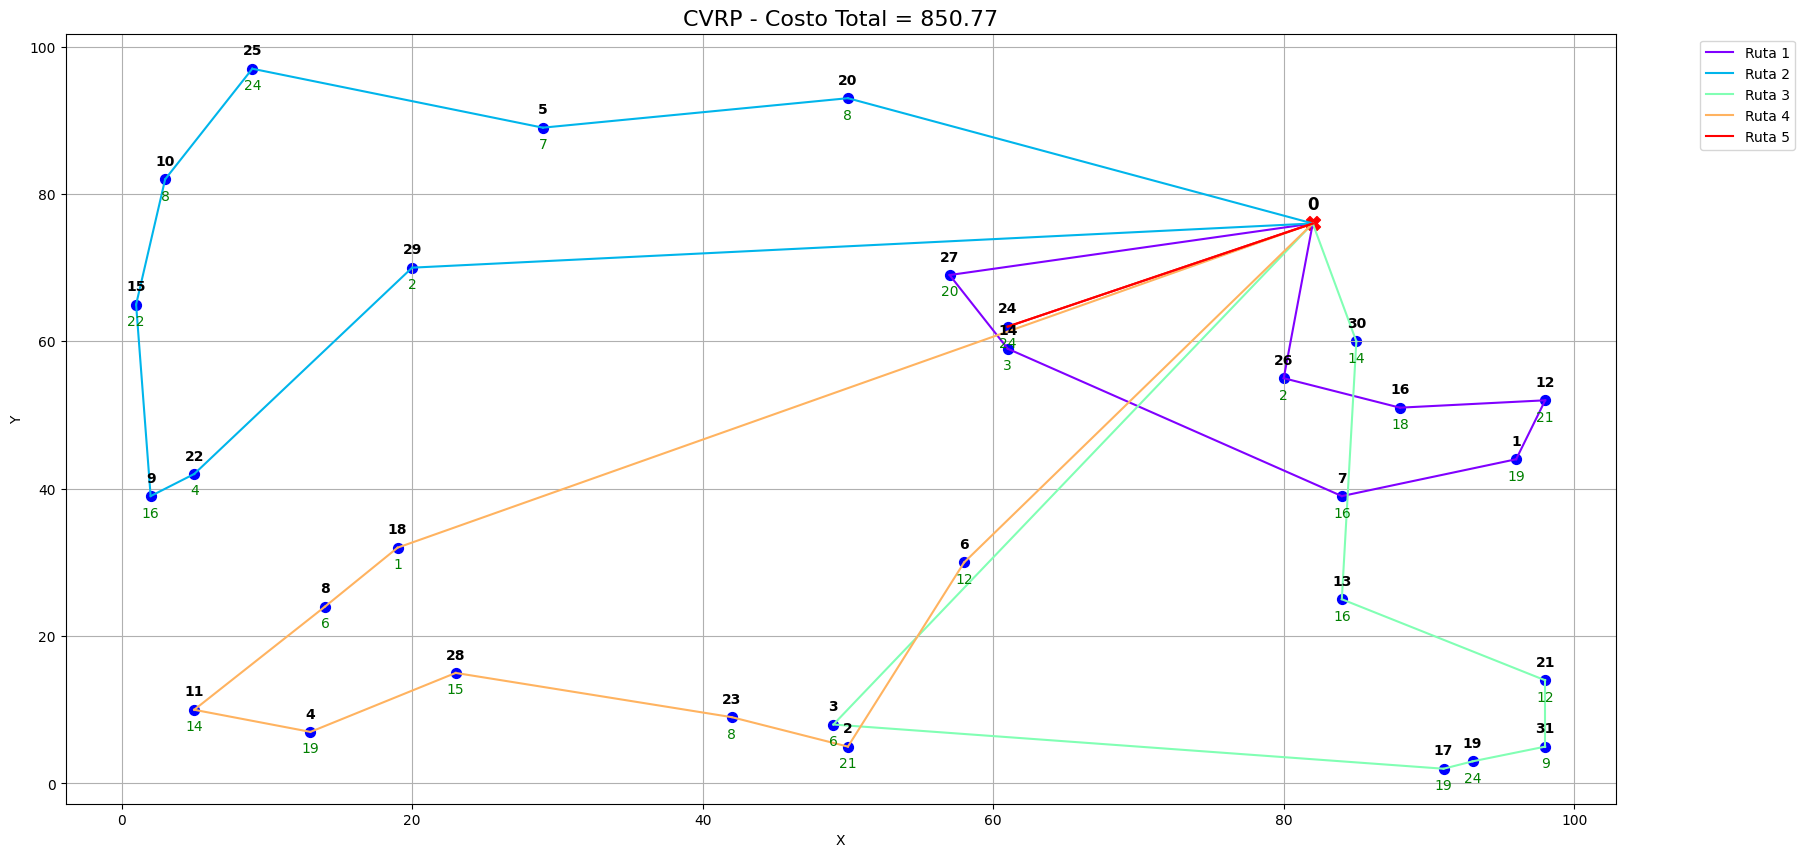

In [29]:
from vrp.Algoritmo_Genetico_CVRP import GeneticAlgorithm
# Probamos el algoritmo genetico
ag = GeneticAlgorithm(cvrp=cvrp, population_size=100, num_generations=340, mutation_rate=0.02, use_elitism=True,gready=True,homogenia=False)
ind,cost,rutas = ag.evolve()
cvrp.graficar(rutas=rutas)

# Creamos una Clase para generacion de imagenes .png

In [1]:
from vrp.Lectura_Instancia import VRPFileReader
from vrp.Problema_CVRP import CVRP
from django.conf import settings

class Image_Controler():
    def __init__(self):
        super().__init__()       
        self.BASE_DIR_IMAGE = os.path.join(settings.BASE_DIR, 'vrp', 'static','imagenes_pruebas')
        self.BASE_DIR_INSTANCIAS =os.path.join(settings.BASE_DIR, 'vrp', 'static', 'instancias')
        self.json_data = {}
        self.cvrp = None
    
    def generate_image_json(self,instancias):
        # las intancias son de la forma : ['A/A-n32-k5.vrp','A/A-n33-k5.vrp',...]
        for instancia in instancias:
            file_path = os.path.join(self.BASE_DIR_INSTANCIAS, instancia)
            filename = os.path.basename(instancia).replace('.vrp','')
            save_path = os.path.join(self.BASE_DIR_IMAGE,'instancia',f'{filename}.png')
            self.cvrp = CVRP(file_path=file_path , file_save = save_path)
            self.cvrp.graficar()

            # Guardamos la instancia solucion
            solution_file_path = file_path.replace('.vrp', '.sol')
            routes_solution, cost_sol = VRPFileReader.read_sol_file(solution_file_path)
            solution_graph_file_path = os.path.join(self.BASE_DIR_IMAGE,'solucion' ,f'{filename}_sol.png')
            self.cvrp.file_save = solution_graph_file_path
            self.cvrp.graficar(routes_solution)

            # Rellenamos el json
            self.json_data[instancia] = {
                'name': instancia,
                'graph_path': save_path,
                'solution_path': solution_graph_file_path,
                'cost_sol': cost_sol,
                'params_ag': [{
                    #population_size, num_generations, mutation_rate, use_elitism=True, gready = False ,homogenia=True
                    'population_size': 50,
                    'num_generations': 5000,
                    'mutation_rate': 0.02,
                    'use_elitism': True,
                    'gready': False,
                    'homogenia': False                  
                },
                {
                    'population_size': 100,
                    'num_generations': 1000,
                    'mutation_rate': 0.02,
                    'use_elitism': True,
                    'gready': True,
                    'homogenia': True
                },
                {
                    'population_size': 250,
                    'num_generations': 2000,
                    'mutation_rate': 0.02,
                    'use_elitism': True,
                    'gready': True,
                    'homogenia': False
                }]
            }
        return self.json_data
        

ModuleNotFoundError: No module named 'vrp'

In [45]:
filename = os.path.basename('A/A-n32-k5.vrp')
filename

'A-n32-k5.vrp'

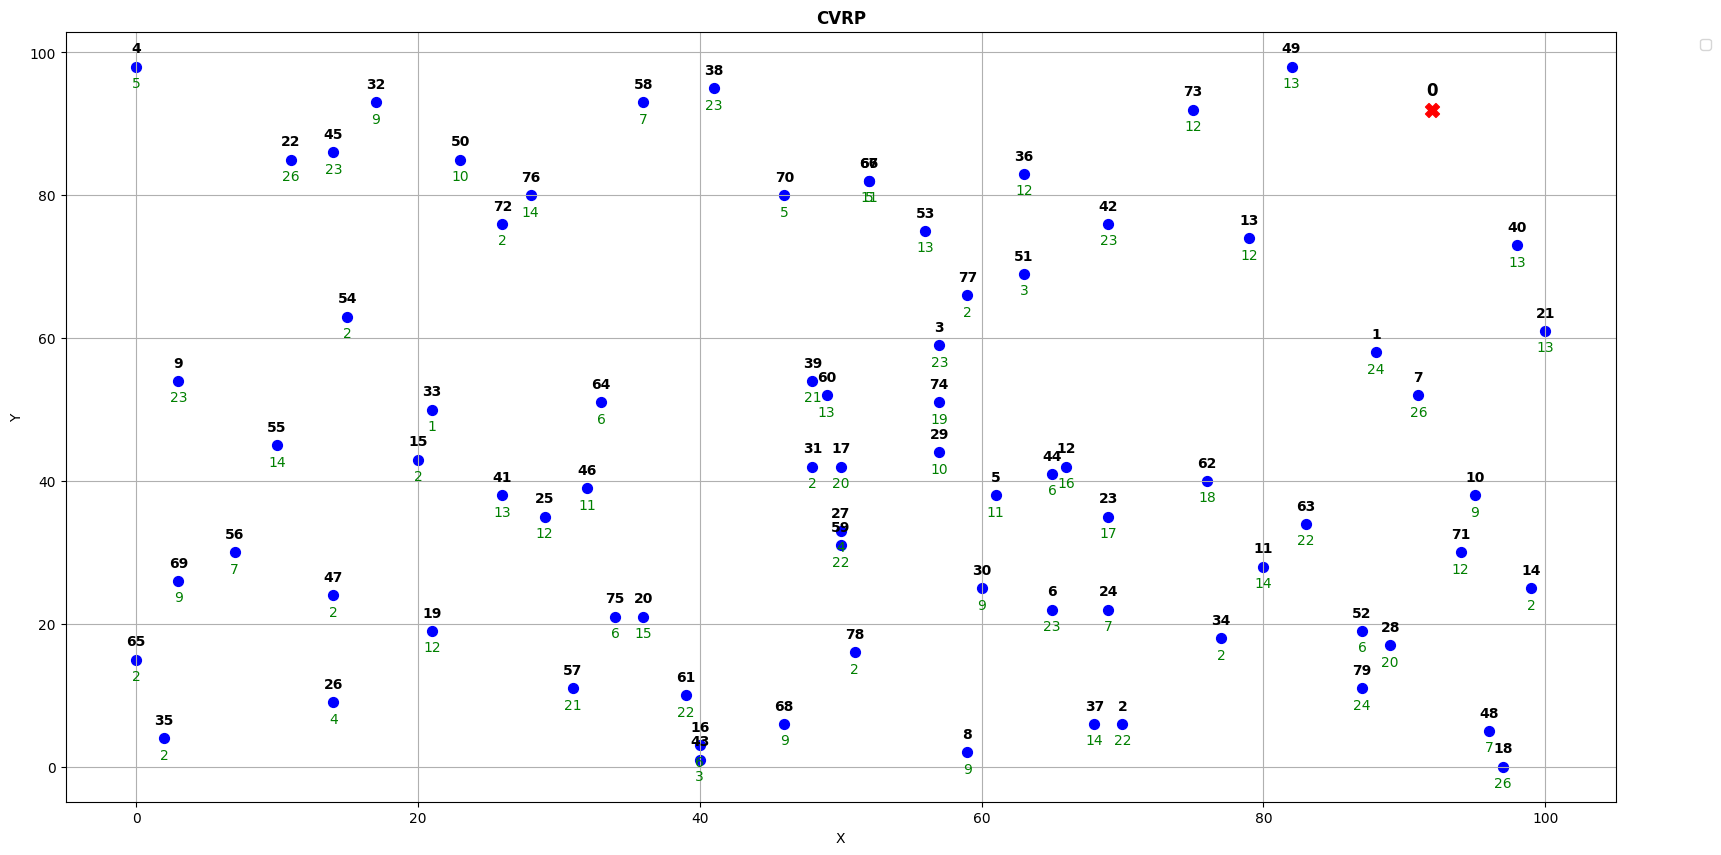

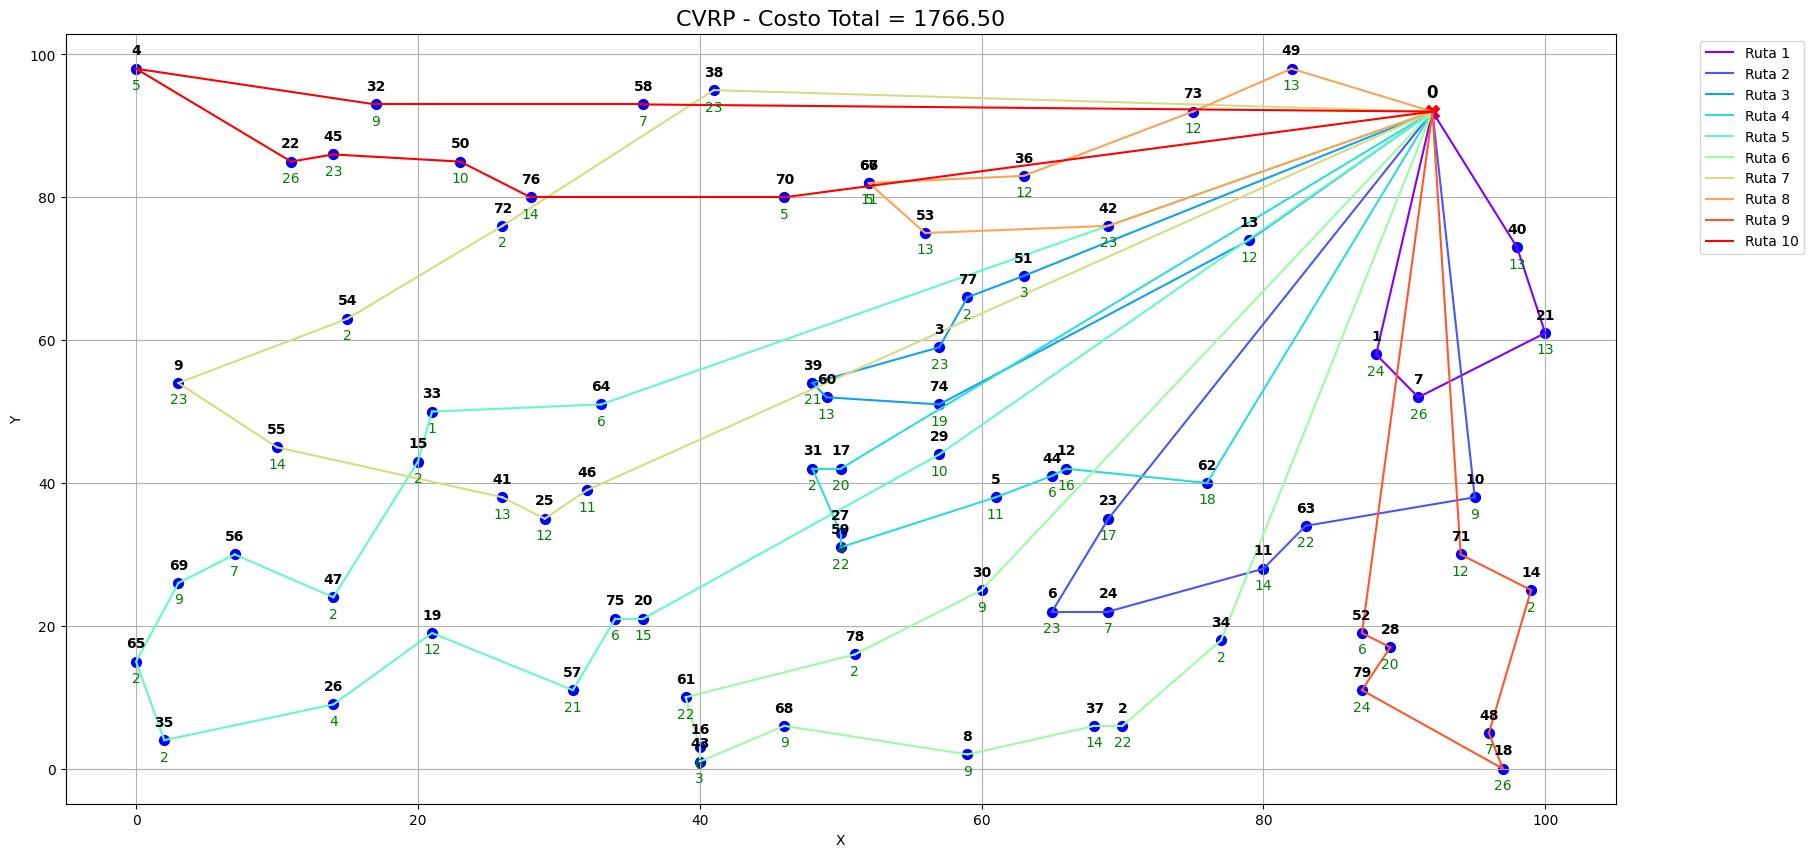

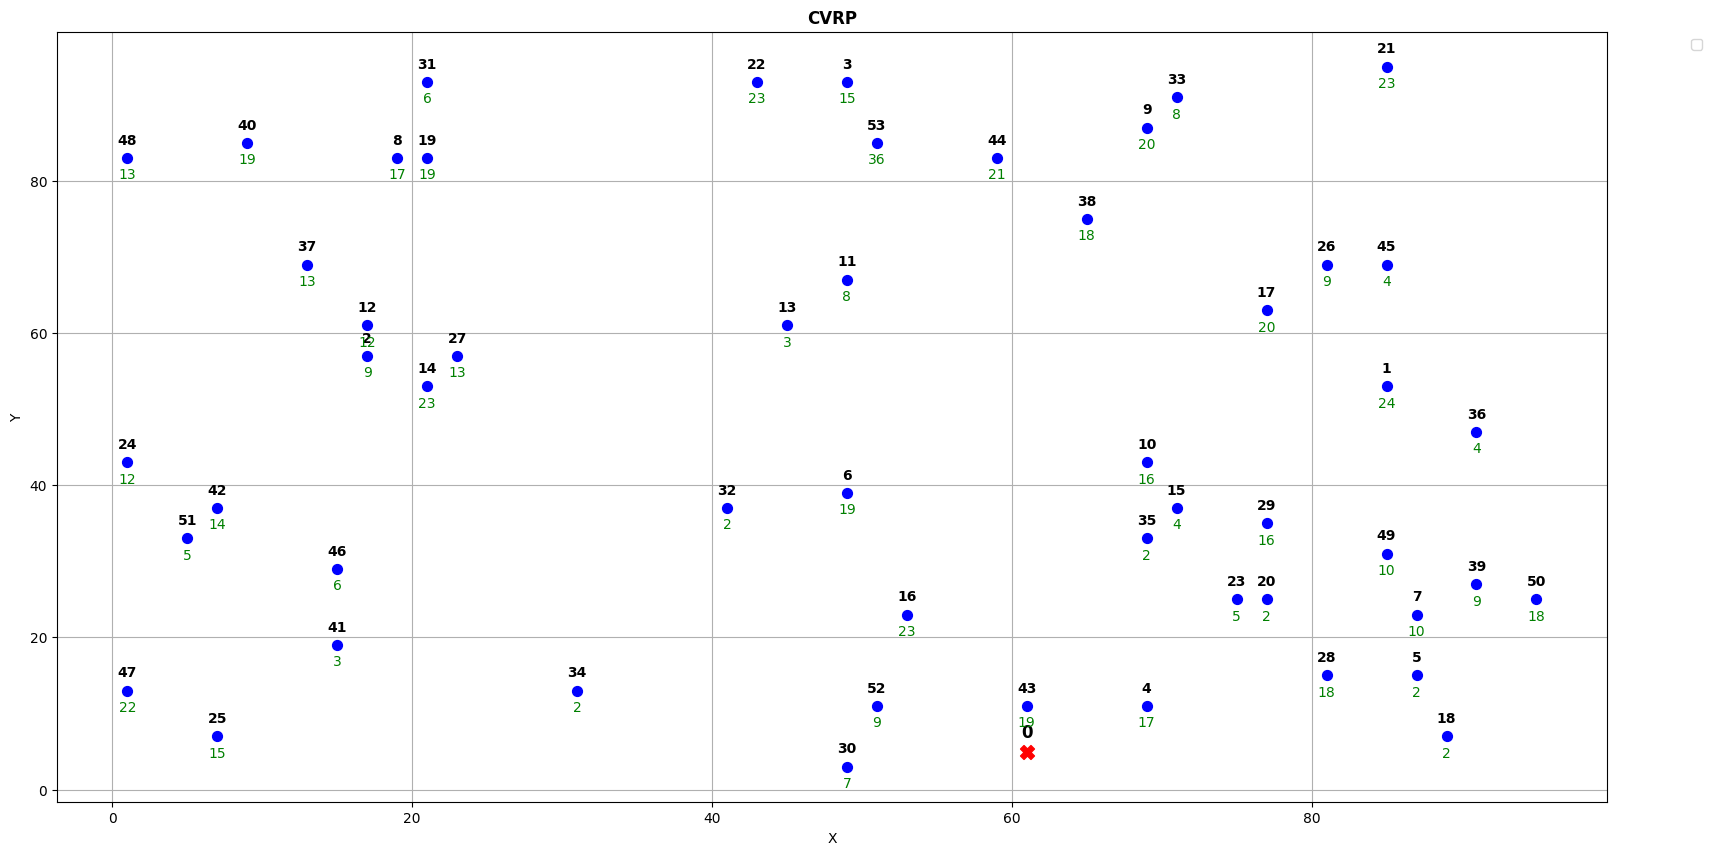

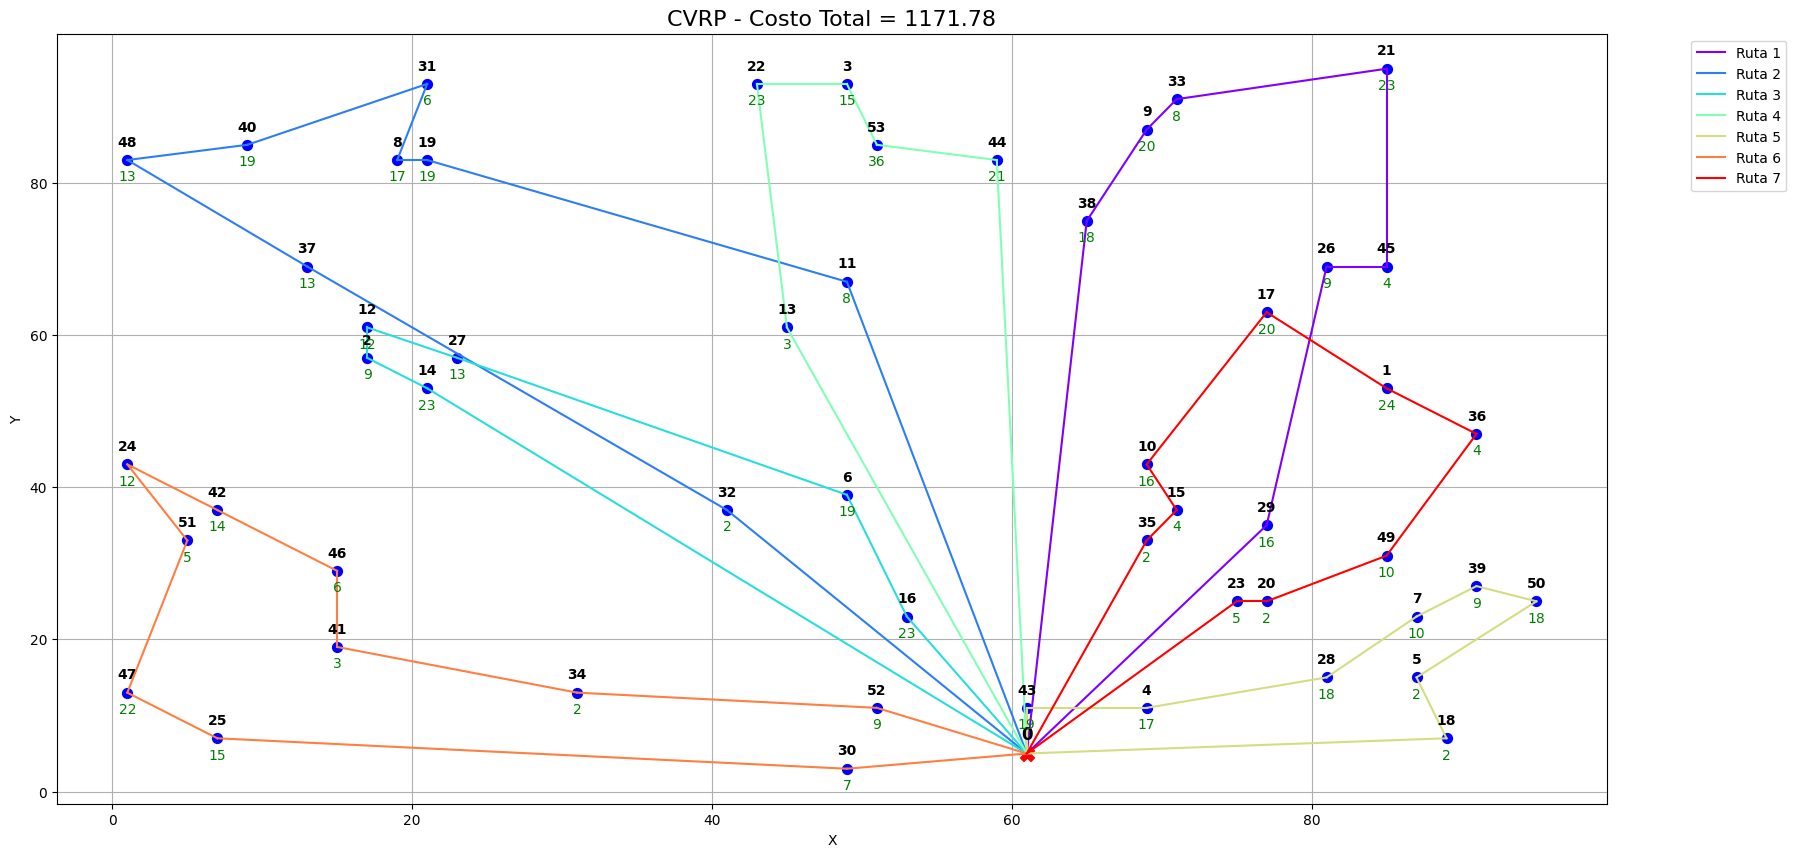

In [47]:
# Creamos una lista de instancias
list_instancias = ['A/A-n80-k10.vrp','A/A-n54-k7.vrp']

ic = Image_Controler()
json_data = ic.generate_image_json(list_instancias)

In [2]:
dic = {
    'a':1,
    'b':2,
    'c':3
}

for a in dic:
    print(a)

a
b
c


In [5]:
import numpy as np
import math

def calcular_matriz_distancias(coords):
    n = len(coords)
    matriz = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            distancia = math.sqrt((coords[i][1] - coords[j][1]) ** 2 + (coords[i][2] - coords[j][2]) ** 2)
            matriz[i][j] = distancia
    return matriz

def calcular_costo_total(matriz, rutas):
    costo_total = 0
    for ruta in rutas:
        ruta_con_depot = [0] + ruta + [0]  # Añadir depósito al inicio y al final de la ruta
        for i in range(len(ruta_con_depot) - 1):
            costo_total += matriz[ruta_con_depot[i]][ruta_con_depot[i + 1]]
    return costo_total

# Coordenadas de los nodos (incluyendo el depósito en la posición 0)
coords = [
    (0, 82, 76),  # Depósito
    (1, 96, 44),
    (2, 50, 5),
    (3, 49, 8),
    (4, 13, 7),
    (5, 29, 89),
    (6, 58, 30),
    (7, 84, 39),
    (8, 14, 24),
    (9, 2, 39),
    (10, 3, 82),
    (11, 5, 10),
    (12, 98, 52),
    (13, 84, 25),
    (14, 61, 59),
    (15, 1, 65),
    (16, 88, 51),
    (17, 91, 2),
    (18, 19, 32),
    (19, 93, 3),
    (20, 50, 93),
    (21, 98, 14),
    (22, 5, 42),
    (23, 42, 9),
    (24, 61, 62),
    (25, 9, 97),
    (26, 80, 55),
    (27, 57, 69),
    (28, 23, 15),
    (29, 20, 70),
    (30, 85, 60),
    (31, 98, 5)
]


#Route #1: 21 31 19 17 13 7 26
#Route #2: 12 1 16 30
#Route #3: 27 24
#Route #4: 29 18 8 9 22 15 10 25 5 20
#Route #5: 14 28 11 4 23 3 2 6
#Cost 784


# Rutas proporcionadas
rutas = [
    [21, 31, 19, 17, 13, 7, 26],
    [12, 1, 16, 30],
    [27, 24],
    [29, 18, 8, 9, 22, 15, 10, 25, 5, 20],
    [14, 28, 11, 4, 23, 3, 2, 6]
]



# Calcular la matriz de distancias
matriz_distancias = calcular_matriz_distancias(coords)

# Calcular el costo total
costo_total = calcular_costo_total(matriz_distancias, rutas)
print(f"Cost: {costo_total}")


Cost: 787.8082774366645


In [6]:
rutas

[[21, 31, 19, 17, 13, 7, 26],
 [12, 1, 16, 30],
 [27, 24],
 [29, 18, 8, 9, 22, 15, 10, 25, 5, 20],
 [14, 28, 11, 4, 23, 3, 2, 6]]

In [8]:
# imprimir matriz de distancias
print(matriz_distancias)

[[  0.          34.92849839  77.87810989 ...  62.28964601  16.2788206
   72.78049189]
 [ 34.92849839   0.          60.30754513 ...  80.32434251  19.41648784
   39.05124838]
 [ 77.87810989  60.30754513   0.         ...  71.58910532  65.19202405
   48.        ]
 ...
 [ 62.28964601  80.32434251  71.58910532 ...   0.          65.76473219
  101.53324579]
 [ 16.2788206   19.41648784  65.19202405 ...  65.76473219   0.
   56.5154846 ]
 [ 72.78049189  39.05124838  48.         ... 101.53324579  56.5154846
    0.        ]]


In [14]:
# completamos la columna solucion de la tabla bechmark
from vrp.tables_genetic import GeneticAlgorithmTable

controller = GeneticAlgorithmTable(lista_modelos=None).complete_solution_cost()

SynchronousOnlyOperation: You cannot call this from an async context - use a thread or sync_to_async.